# Fabio Arayya Pratama
# 24083010064
# MACHINE LEARNING D

### TO3 **Perbandindan dengan dataset "Store Item Demand Forecasting Challenge"**

# Install Library Dataset

In [24]:
import pandas as pd

In [25]:
from google.colab import files

print('Upload file: trainDemand.csv')
uploaded = files.upload()

Upload file: trainDemand.csv


Saving trainDemand.csv to trainDemand (2).csv


In [26]:
df_demand = pd.read_csv('trainDemand.csv')

print(df_demand.head())

         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10


In [27]:
# Informasi struktur data
print(df_demand.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB
None


In [28]:
# Statistik Deskriptif
print(df_demand.describe())

               store           item          sales
count  913000.000000  913000.000000  913000.000000
mean        5.500000      25.500000      52.250287
std         2.872283      14.430878      28.801144
min         1.000000       1.000000       0.000000
25%         3.000000      13.000000      30.000000
50%         5.500000      25.500000      47.000000
75%         8.000000      38.000000      70.000000
max        10.000000      50.000000     231.000000


# 2 Identifikasi Variabel Target dan Fitur

In [29]:
# Variabel target
print('VARIABEL TARGET (yang akan diprediksi):')
print('   → Sales')

# Variabel fitur
print('\nVARIABEL FITUR (predictor):')
fitur = [col for col in df_demand.columns if col != 'Sales']
for f in fitur:
    print(f'   → {f}')

# Tipe data setiap kolom
print('\nTIPE DATA SETIAP KOLOM:')
print(df_demand.dtypes)

VARIABEL TARGET (yang akan diprediksi):
   → Sales

VARIABEL FITUR (predictor):
   → date
   → store
   → item
   → sales

TIPE DATA SETIAP KOLOM:
date     object
store     int64
item      int64
sales     int64
dtype: object


# 3 Data Pre-Processing

In [30]:
# Cek Missing Value
print(df_demand.isnull().sum())

date     0
store    0
item     0
sales    0
dtype: int64


# 5 Metode Penanganan Missing Value

Tidak ada missing value yang terdeteksi dalam dataset Demand Forecasting

# 6 Cek Data Duplikat

In [31]:
# Cek Data Duplikasi
print(df_demand.duplicated().sum())

0


# 7 Ubah Kolom Date ke DateTime

In [32]:
df_demand['date'] = pd.to_datetime(df_demand['date'])
print(df_demand.dtypes)

date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object


# 8 Buat Fitu Baru
FITUR ENGINERING

In [33]:
# Fitur Waktu
df_demand['Year'] = df_demand['date'].dt.year
df_demand['Month'] = df_demand['date'].dt.month
df_demand['Week'] = df_demand['date'].dt.isocalendar().week
df_demand['Day'] = df_demand['date'].dt.dayofweek
print(df_demand.head())

        date  store  item  sales  Year  Month  Week  Day
0 2013-01-01      1     1     13  2013      1     1    1
1 2013-01-02      1     1     11  2013      1     1    2
2 2013-01-03      1     1     14  2013      1     1    3
3 2013-01-04      1     1     13  2013      1     1    4
4 2013-01-05      1     1     10  2013      1     1    5


# 9 Jelaskan Mengapa Fitur Waktu Penting dalam Time Series Forecasting

Fitur waktu sangat penting dalam time series forecasting karena penjualan sangat
dipengaruhi oleh faktor waktu. Fitur Year membantu model menangkap tren jangka
panjang, misalnya apakah penjualan secara umum naik atau turun dari tahun ke
tahun. Fitur Month dan Week membantu model mengenali pola musiman seperti lonjakan
penjualan saat hari libur nasional atau periode promosi yang terjadi berulang
setiap tahunnya. Fitur Day_of_Week membantu model memahami perbedaan pola belanja
antara hari kerja dan akhir pekan. Tanpa fitur-fitur waktu ini, model tidak akan
bisa mengenali pola temporal yang justru menjadi inti dari peramalan deret waktu.


# 10 Buat Lag Feature

In [34]:
# Lag Feature
df_demand = df_demand.sort_values(['store','item','date'])

df_demand['Lag_1'] = df_demand.groupby(['store','item'])['sales'].shift(1)
df_demand['Lag_7'] = df_demand.groupby(['store','item'])['sales'].shift(7)
df_demand['Lag_30'] = df_demand.groupby(['store','item'])['sales'].shift(30)
print(df_demand.head())

        date  store  item  sales  Year  Month  Week  Day  Lag_1  Lag_7  Lag_30
0 2013-01-01      1     1     13  2013      1     1    1    NaN    NaN     NaN
1 2013-01-02      1     1     11  2013      1     1    2   13.0    NaN     NaN
2 2013-01-03      1     1     14  2013      1     1    3   11.0    NaN     NaN
3 2013-01-04      1     1     13  2013      1     1    4   14.0    NaN     NaN
4 2013-01-05      1     1     10  2013      1     1    5   13.0    NaN     NaN


# **11. Fungsi Lag Feature dalam Model Peramalan**
Lag feature berfungsi memberikan informasi historis kepada model Machine Learning
sehingga model bisa belajar dari pola penjualan di masa lalu untuk memprediksi
nilai di masa depan. Dalam konteks penjualan harian, nilai hari ini sangat
dipengaruhi oleh nilai hari-hari sebelumnya. Dengan adanya Lag_1, Lag_2, dan
Lag_4, model bisa mendeteksi pola jangka pendek seperti tren naik atau turun
dalam beberapa hari terakhir, maupun pola yang berulang setiap 4 hari sekali.
Tanpa lag feature, model hanya melihat data statis tanpa konteks historis apapun.

# 12 Buat Fitur Rolling Mean

In [35]:
# Rolling Mean
df_demand['Rolling_7'] = df_demand.groupby(['store','item'])['sales']\
                   .transform(lambda x: x.rolling(7).mean())

print(df_demand.head())

        date  store  item  sales  Year  Month  Week  Day  Lag_1  Lag_7  \
0 2013-01-01      1     1     13  2013      1     1    1    NaN    NaN   
1 2013-01-02      1     1     11  2013      1     1    2   13.0    NaN   
2 2013-01-03      1     1     14  2013      1     1    3   11.0    NaN   
3 2013-01-04      1     1     13  2013      1     1    4   14.0    NaN   
4 2013-01-05      1     1     10  2013      1     1    5   13.0    NaN   

   Lag_30  Rolling_7  
0     NaN        NaN  
1     NaN        NaN  
2     NaN        NaN  
3     NaN        NaN  
4     NaN        NaN  


# 13 Visualisasi untuk Mendeteksi Outlier
- Boxplot
- Histogram

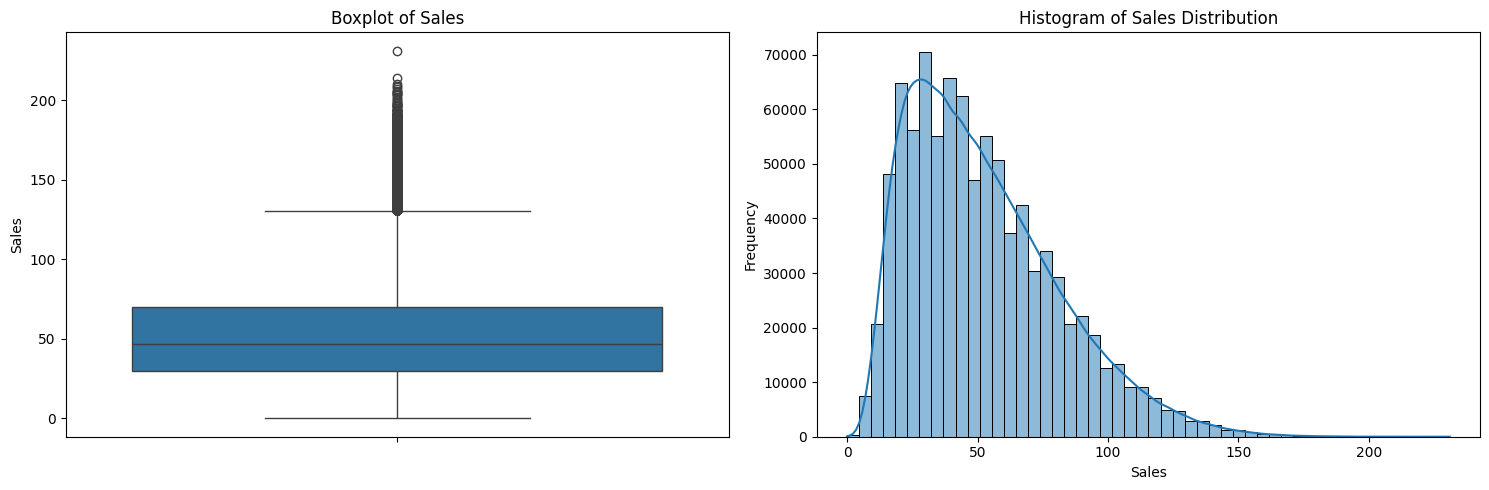

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Boxplot for 'sales' to detect outliers
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=df_demand['sales'])
plt.title('Boxplot of Sales')
plt.ylabel('Sales')

# Histogram for 'sales' to see distribution and potential outliers
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df_demand['sales'], bins=50, kde=True)
plt.title('Histogram of Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 14 jelaskan minimal dua metode untuk menngani outlier

- Penghapusan (Removal): Metode ini adalah yang paling sederhana. Jika Anda yakin outlier tersebut adalah kesalahan input data atau berasal dari anomali yang tidak akan terulang, Anda dapat langsung menghapus baris data yang mengandung outlier tersebut. Namun, perlu hati-hati karena menghapus terlalu banyak data dapat mengurangi ukuran dataset dan berpotensi menghilangkan informasi penting.

- Transformasi (Transformation): Metode ini melibatkan penerapan fungsi matematika pada data untuk mengurangi dampak outlier dan membuat distribusi data lebih simetris atau mendekati normal. Contoh transformasi yang umum digunakan adalah transformasi logaritma (misalnya, np.log(data)) atau transformasi akar kuadrat (np.sqrt(data)). Transformasi ini 'menekan' nilai-nilai ekstrem, sehingga outlier tidak lagi terlalu jauh dari nilai-nilai lainnya relatif terhadap skala baru.

### Implementasi Penanganan Outlier dengan Metode Transformasi (Logaritma)

   sales  sales_log
0     13   2.639057
1     11   2.484907
2     14   2.708050
3     13   2.639057
4     10   2.397895


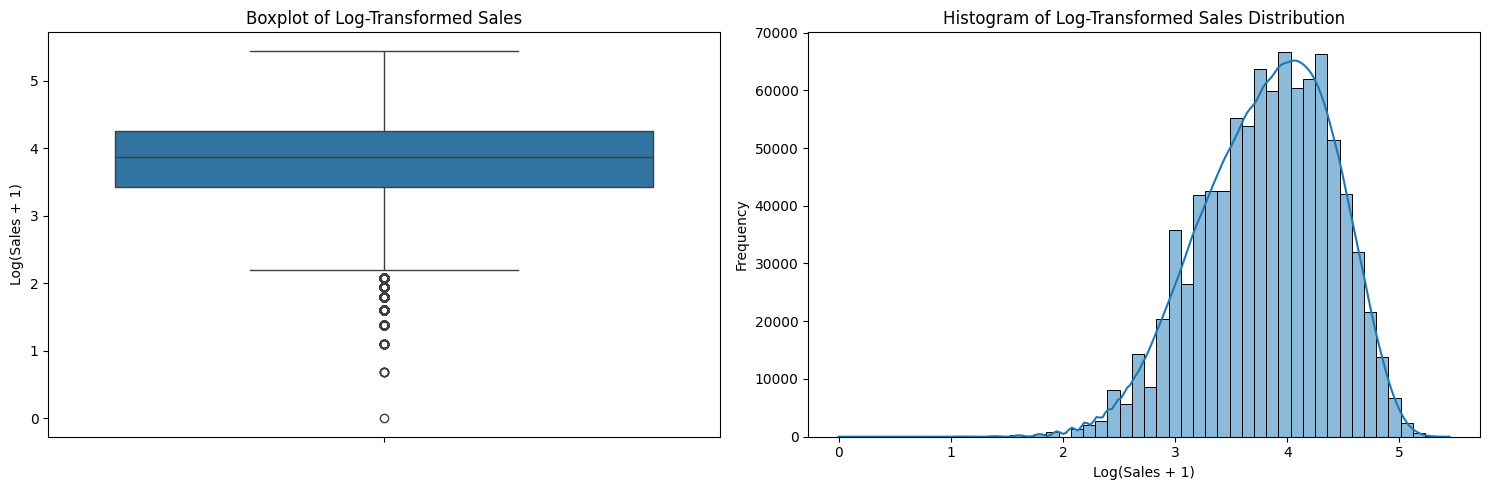

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply logarithmic transformation to 'sales'
# Add a small constant to handle zero sales values if they exist, to avoid log(0)
df_demand['sales_log'] = np.log1p(df_demand['sales'])

print(df_demand[['sales', 'sales_log']].head())

# Visualize the distribution of transformed sales
plt.figure(figsize=(15, 5))

# Boxplot for transformed 'sales'
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=df_demand['sales_log'])
plt.title('Boxplot of Log-Transformed Sales')
plt.ylabel('Log(Sales + 1)')

# Histogram for transformed 'sales'
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df_demand['sales_log'], bins=50, kde=True)
plt.title('Histogram of Log-Transformed Sales Distribution')
plt.xlabel('Log(Sales + 1)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 15 Standarisasi Variabel Numerik

In [39]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

# Identify numerical features for scaling (excluding 'sales' which is usually the target)
# And excluding 'store', 'item' which are categorical identifiers, and 'date' as it's datetime.
numerical_features = ['Year', 'Month', 'Week', 'Day', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_7']

# Create a copy to work on, to preserve the original df_demand
df_processed = df_demand.copy()

# Handle NaN values in the identified numerical features BEFORE scaling
# For time-series, often NaNs appear at the beginning due to lag/rolling calculations.
# A common approach is to drop these rows if they are limited, or impute.
# Here, we will drop rows where any of these critical features are NaN.
initial_rows = df_processed.shape[0]
df_processed.dropna(subset=numerical_features, inplace=True)
rows_after_dropna = df_processed.shape[0]

print(f"Number of rows before NaN handling: {initial_rows}")
print(f"Number of rows after dropping NaNs in numerical features: {rows_after_dropna}")
print(f"Number of rows dropped: {initial_rows - rows_after_dropna}\n")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standardization to the selected numerical features
# Note: We are transforming these columns in place within df_processed
df_processed[numerical_features] = scaler.fit_transform(df_processed[numerical_features])

print("DataFrame after standardization (first 5 rows with scaled features):")
display(df_processed[['date', 'store', 'item', 'sales'] + numerical_features].head())

# Also show a descriptive statistic of one scaled column to verify scaling
print("\nDescriptive statistics for a scaled feature (e.g., 'Lag_1'):")
print(df_processed['Lag_1'].describe())

Number of rows before NaN handling: 913000
Number of rows after dropping NaNs in numerical features: 898000
Number of rows dropped: 15000

DataFrame after standardization (first 5 rows with scaled features):


,date,store,item,sales,Year,Month,Week,Day,Lag_1,Lag_7,Lag_30,Rolling_7
30,2013-01-31,1,1,13,-1.451026,-1.650790,-1.480907,-0.001671,-1.513334,-1.545923,-1.363562,-1.540140
31,2013-02-01,1,1,11,-1.451026,-1.356836,-1.480907,0.498400,-1.374554,-1.337834,-1.432822,-1.556007
32,2013-02-02,1,1,21,-1.451026,-1.356836,-1.480907,0.998470,-1.443944,-1.407197,-1.328932,-1.508406
33,2013-02-03,1,1,15,-1.451026,-1.356836,-1.480907,1.498540,-1.096996,-1.407197,-1.363562,-1.492540
34,2013-02-04,1,1,14,-1.451026,-1.356836,-1.413633,-1.501882,-1.305165,-1.441878,-1.467452,-1.476673



Descriptive statistics for a scaled feature (e.g., 'Lag_1'):
count    8.980000e+05
mean     1.899001e-17
std      1.000001e+00
min     -1.825588e+00
25%     -7.847417e-01
50%     -1.949289e-01
75%      6.030531e-01
max      6.188927e+00
Name: Lag_1, dtype: float64


# **16 Perbedaan Min-Max Scaling dan Standardization**
Min-Max Scaling bekerja dengan mengubah semua nilai ke dalam rentang 0 sampai 1
dengan cara mengurangi nilai minimum lalu membagi dengan selisih nilai maksimum
dan minimum. Metode ini cocok ketika kita ingin nilai berada dalam rentang
tertentu, namun kelemahannya sangat sensitif terhadap outlier karena nilai
maksimum dan minimum sangat berpengaruh pada hasil scaling. Standardization
bekerja dengan mengubah nilai sehingga memiliki rata-rata 0 dan standar deviasi 1. Metode ini lebih tahan terhadap outlier dan lebih cocok digunakan pada
algoritma yang mengasumsikan data berdistribusi normal seperti regresi linear
dan SVM.

## 17 Split Data (Time-Series)

In [40]:
split = df_demand['date'].quantile(0.8)

train = df_demand[df_demand['date'] <= split]
test = df_demand[df_demand['date'] > split]

print(train.head())
print(test.head())

        date  store  item  sales  Year  Month  Week  Day  Lag_1  Lag_7  \
0 2013-01-01      1     1     13  2013      1     1    1    NaN    NaN   
1 2013-01-02      1     1     11  2013      1     1    2   13.0    NaN   
2 2013-01-03      1     1     14  2013      1     1    3   11.0    NaN   
3 2013-01-04      1     1     13  2013      1     1    4   14.0    NaN   
4 2013-01-05      1     1     10  2013      1     1    5   13.0    NaN   

   Lag_30  Rolling_7  sales_log  
0     NaN        NaN   2.639057  
1     NaN        NaN   2.484907  
2     NaN        NaN   2.708050  
3     NaN        NaN   2.639057  
4     NaN        NaN   2.397895  
           date  store  item  sales  Year  Month  Week  Day  Lag_1  Lag_7  \
1461 2017-01-01      1     1     19  2017      1    52    6   14.0   20.0   
1462 2017-01-02      1     1     15  2017      1     1    0   19.0   16.0   
1463 2017-01-03      1     1     10  2017      1     1    1   15.0   10.0   
1464 2017-01-04      1     1     16  2017  

In [41]:
X_train = train[['store','item','Year','Month','Week','Lag_1','Lag_7','Rolling_7']]
y_train = train['sales']

X_test = test[['store','item','Year','Month','Week','Lag_1','Lag_7','Rolling_7']]
y_test = test['sales']

print(X_train.head())
print(y_train.head())

   store  item  Year  Month  Week  Lag_1  Lag_7  Rolling_7
0      1     1  2013      1     1    NaN    NaN        NaN
1      1     1  2013      1     1   13.0    NaN        NaN
2      1     1  2013      1     1   11.0    NaN        NaN
3      1     1  2013      1     1   14.0    NaN        NaN
4      1     1  2013      1     1   13.0    NaN        NaN
0    13
1    11
2    14
3    13
4    10
Name: sales, dtype: int64


# **18. Alasan Time Series tidak boleh di shuffle sebelum di split**
Pada data time series, shuffle tidak boleh dilakukan sebelum split karena urutan
waktu adalah informasi yang sangat penting. Jika data diacak, maka data dari masa
depan bisa masuk ke training set sementara data masa lalu masuk ke testing set,
yang menyebabkan model secara tidak langsung melihat masa depan saat proses
pelatihan. Kondisi ini disebut data leakage dan membuat hasil evaluasi model
terlihat bagus padahal tidak mencerminkan performa nyata. Selain itu fitur seperti
lag dan rolling mean akan kehilangan maknanya jika urutan waktu rusak karena
fitur-fitur tersebut bergantung pada urutan kronologis data.

# 19 Eksplorasi Visual Penjualan

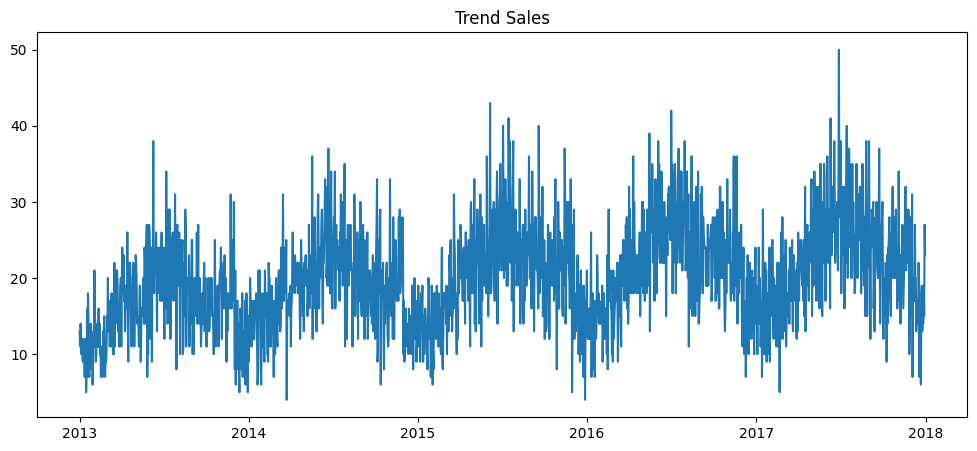

In [38]:
import matplotlib.pyplot as plt

sample = df_demand[(df_demand['store']==1) & (df_demand['item']==1)]

plt.figure(figsize=(12,5))
plt.plot(sample['date'], sample['sales'])
plt.title("Trend Sales")
plt.show()

# **ANALISIS DATASET STORE ITEM DEMAND FORECASTING**
Karakteristik:
- pola cukup stabil
- noise rendah
- tidak ada faktor eksternal

# **20 Identifikasi apakah data memiliki:**
	•	trend
	•	seasonality
	•	noise.

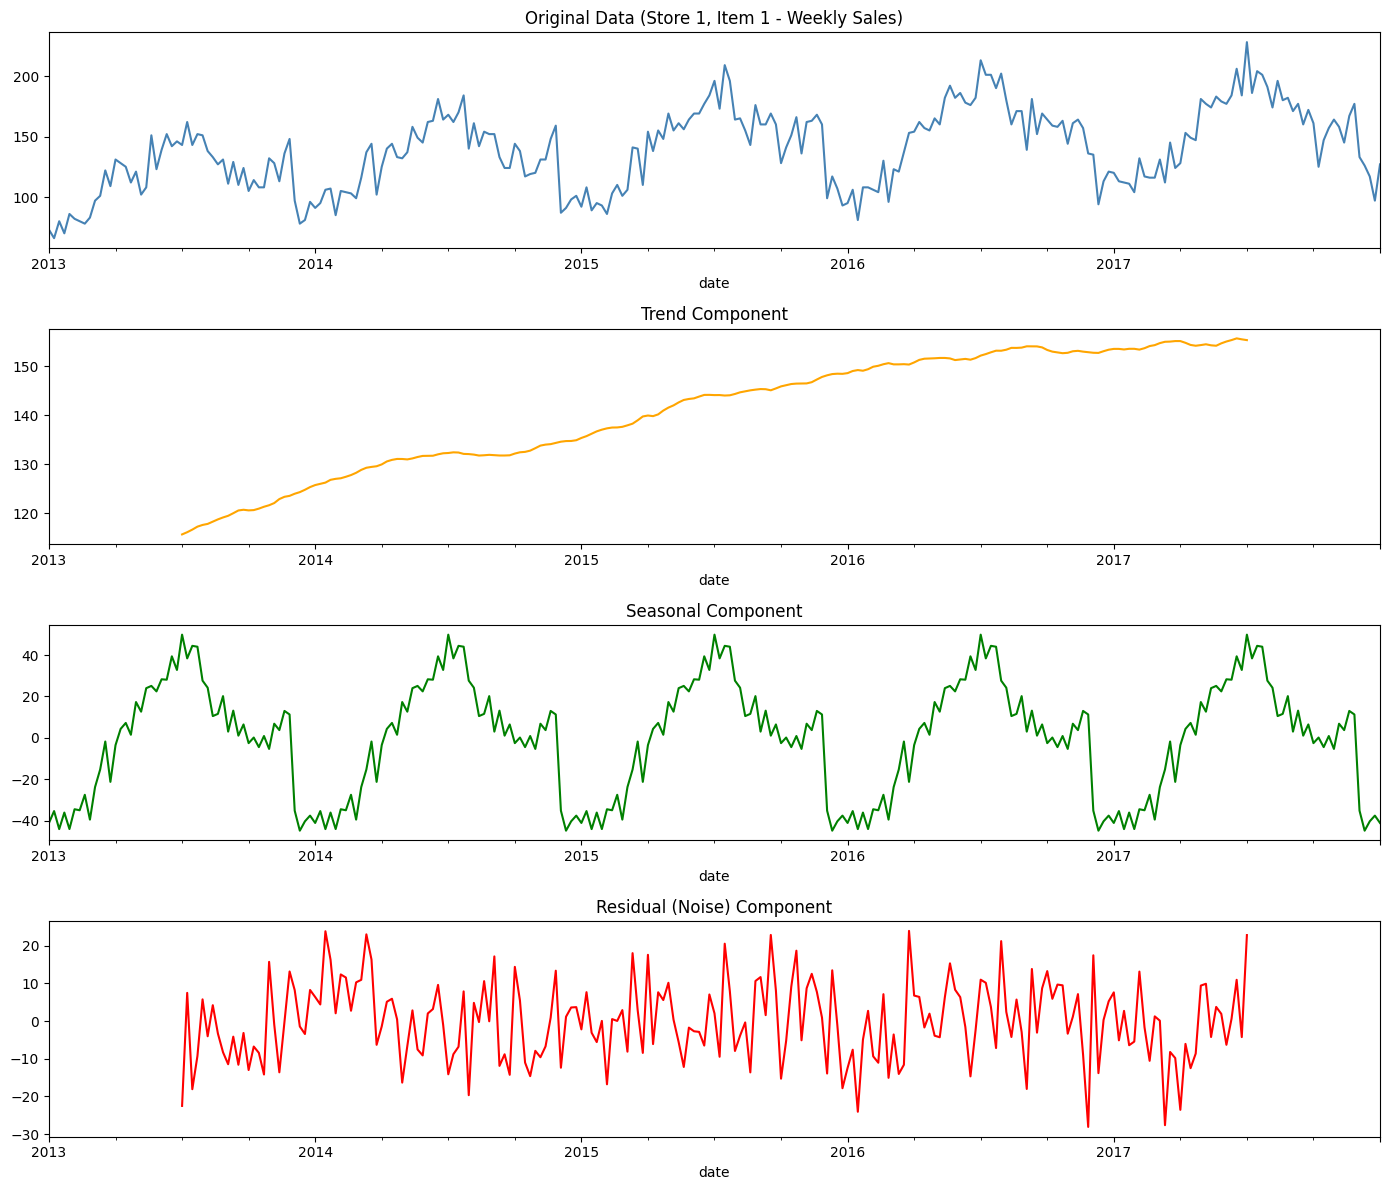

In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for Store 1 and Item 1, then aggregate weekly
# Make a copy to avoid SettingWithCopyWarning
store_item_weekly = df_demand[(df_demand['store'] == 1) & (df_demand['item'] == 1)].copy()
store_item_weekly = store_item_weekly.set_index('date')['sales'].resample('W').sum()

# Perform additive seasonal decomposition with a period of 52 (for weekly data over a year)
decomposition = seasonal_decompose(store_item_weekly, model='additive', period=52)

# Plot the decomposition results
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

store_item_weekly.plot(ax=axes[0], title='Original Data (Store 1, Item 1 - Weekly Sales)', color='steelblue')
decomposition.trend.plot(ax=axes[1], title='Trend Component', color='orange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual (Noise) Component', color='red')

plt.tight_layout()
plt.show()

# **Identifikasi karakteristik data:**

- Trend: Data menunjukkan adanya trend yang men-ingkat seiring waktu. Penjualan cenderung mengalami kenaikan secara keseluruhan dari tahun ke tahun.
- Seasonality (Pola Musiman): Terdapat pola musiman yang jelas. Anda dapat melihat fluktuasi penjualan yang berulang secara periodik dalam setiap tahun (misalnya, puncak dan lembah penjualan yang terjadi pada waktu yang sama setiap tahun). Ini menunjukkan bahwa ada faktor-faktor musiman yang mempengaruhi penjualan.
- Noise (Kebisingan): Analisis sebelumnya menyebutkan 'noise rendah'. Ini berarti variasi atau fluktuasi acak dalam data relatif kecil dan tidak terlalu dominan dibandingkan dengan trend dan pola musiman. Data cukup bersih dan stabil, sehingga pola dasarnya mudah diidentifikasi.

# **Perbandingan Pemodelan Dataset**


Tren Penjualan

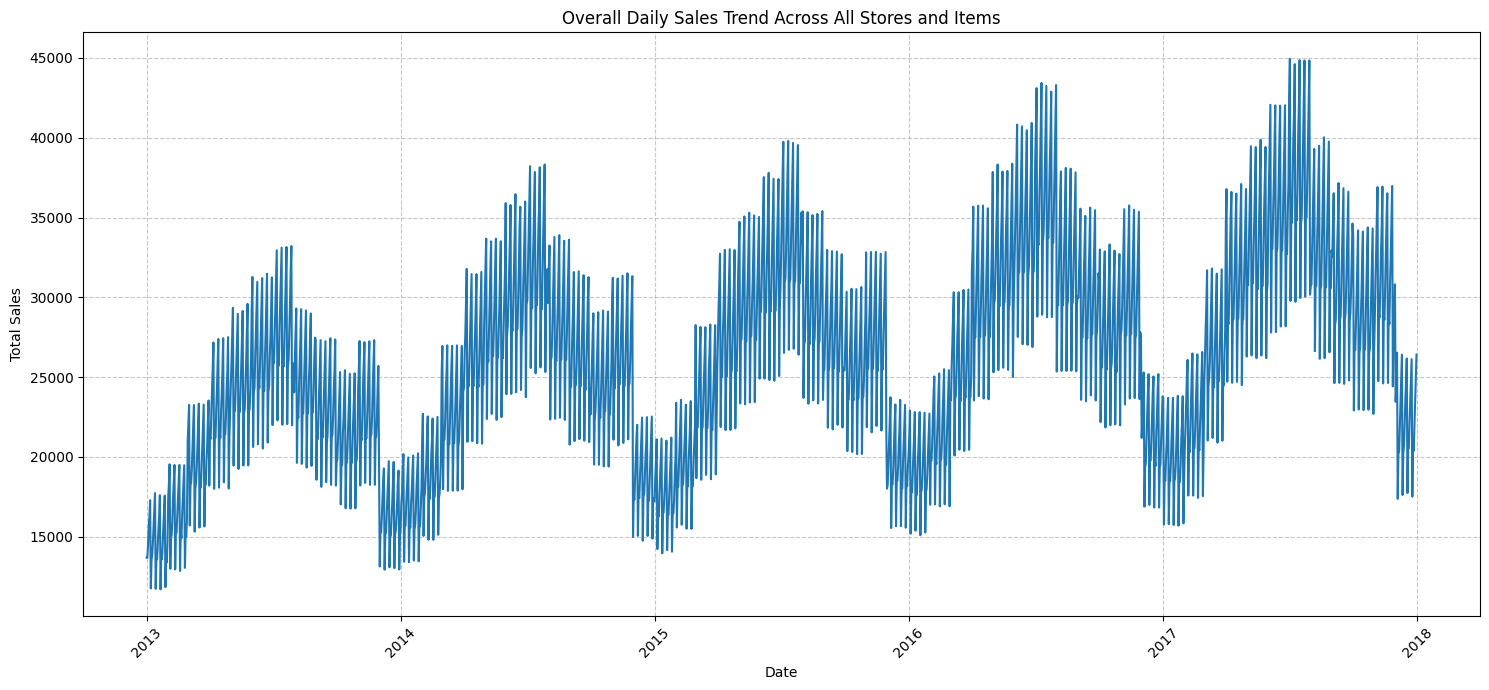

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agregasi penjualan harian secara keseluruhan
daily_overall_sales = df_demand.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='date', y='sales', data=daily_overall_sales)
plt.title('Overall Daily Sales Trend Across All Stores and Items')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Analisis Perbandingan Dataset Wallmart dengan Store Item Demand Forecasting**

Berdasarkan hasil eksplorasi dan visualisasi, terdapat perbedaan karakteristik yang signifikan antara dataset Walmart dan dataset Store Item Demand Forecasting.

Distribusi penjualan pada dataset Walmart menunjukkan variabilitas yang tinggi dengan banyak nilai ekstrem (outlier), yang mengindikasikan adanya fluktuasi penjualan yang besar. Sebaliknya, dataset Demand memiliki distribusi yang lebih stabil dan mendekati normal.

Dari sisi tren, dataset Walmart menunjukkan pola yang lebih kompleks dengan banyak lonjakan yang dipengaruhi oleh faktor eksternal seperti musim dan hari libur. Sementara itu, dataset Demand memiliki pola yang lebih halus dan konsisten.

Selain itu, variasi antar toko pada dataset Walmart lebih besar dibandingkan dataset Demand, yang menunjukkan heterogenitas yang lebih tinggi.

Berdasarkan hasil evaluasi model, dataset Demand cenderung menghasilkan nilai error yang lebih rendah dibandingkan Walmart. Hal ini menunjukkan bahwa dataset Demand lebih mudah diprediksi karena memiliki tingkat noise yang lebih rendah dan pola yang lebih stabil.